<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day14_Text_Preprocessing().ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
data = {
    'review_id': list(range(1, 26)),
    'product': [
        'Wireless Headphones', 'Wireless Headphones', 'Laptop Stand', 'Laptop Stand',
        'USB-C Hub', 'USB-C Hub', 'Mechanical Keyboard', 'Mechanical Keyboard',
        'Webcam HD', 'Webcam HD', 'Mouse Pad XL', 'Mouse Pad XL',
        'Monitor Light', 'Monitor Light', 'Desk Organizer', 'Desk Organizer',
        'Wireless Headphones', 'Laptop Stand', 'USB-C Hub', 'Mechanical Keyboard',
        'Webcam HD', 'Mouse Pad XL', 'Monitor Light', 'Desk Organizer', 'Wireless Headphones'
    ],
    'review_text': [
        'I love these headphones! The sound quality is amazing and the battery lasts forever 🎧🔥',
        'Worst headphones I have ever bought. The Bluetooth keeps disconnecting 😡',
        'Great stand for my laptop. Sturdy build and good height adjustment.',
        'This stand is terrible. It wobbles and feels cheap. Very disappointed!',
        'Excellent hub with fast data transfer speeds. Works perfectly with my MacBook! 👍',
        'The hub stopped working after 2 weeks. Poor quality product.',
        'Best keyboard I have ever used! The tactile feedback is fantastic 😍⌨️',
        'Keys started sticking after a month. Not happy with this purchase.',
        'Good webcam for the price. Video quality is decent for Zoom calls.',
        'Horrible webcam!! The image is blurry and the microphone picks up everything 😤',
        'Nice mouse pad. Large enough for my whole desk setup.',
        'The pad curls up at the edges. Frustrating experience overall.',
        'This monitor light is wonderful! Reduces eye strain significantly 💡✨',
        'Bad product. The light flickers constantly and gives me headaches.',
        'Amazing organizer! Keeps my desk clean and everything in reach 🙌',
        'Awful quality. The compartments are too small and it broke within a week.',
        'Happy with this purchase. Sound is clear and comfortable to wear all day.',
        'It does the job. Nothing special but works as expected.',
        'I hate that the ports are so close together! Makes it hard to use multiple USB drives at once 😠',
        'Awesome keyboard for gaming and typing!! The RGB lighting is beautiful! 🎮🌈',
        'Satisfied with the webcam. Easy setup and good software support.',
        'Just an average mouse pad. Does what it needs to do.',
        'Great light bar! Easy to install and the brightness levels are perfect.',
        'Disappointed with the size. Looked bigger in the photos.',
        'These headphones are great for the price!! Excellent noise cancellation! 🎶'
    ],
    'rating': [5, 1, 4, 1, 5, 2, 5, 2, 3, 1, 4, 2, 5, 1, 5, 1, 4, 3, 2, 5, 4, 3, 4, 2, 5]
}

df_reviews = pd.DataFrame(data)
print(f'Dataset shape: {df_reviews.shape}')
print(f'Columns: {list(df_reviews.columns)}')
df_reviews.head(10)

Dataset shape: (25, 4)
Columns: ['review_id', 'product', 'review_text', 'rating']


,review_id,product,review_text,rating
0,1,Wireless Headphones,I love these headphones! The sound quality is ...,5
1,2,Wireless Headphones,Worst headphones I have ever bought. The Bluet...,1
2,3,Laptop Stand,Great stand for my laptop. Sturdy build and go...,4
3,4,Laptop Stand,This stand is terrible. It wobbles and feels c...,1
4,5,USB-C Hub,Excellent hub with fast data transfer speeds. ...,5
5,6,USB-C Hub,The hub stopped working after 2 weeks. Poor qu...,2
6,7,Mechanical Keyboard,Best keyboard I have ever used! The tactile fe...,5
7,8,Mechanical Keyboard,Keys started sticking after a month. Not happy...,2
8,9,Webcam HD,Good webcam for the price. Video quality is de...,3
9,10,Webcam HD,Horrible webcam!! The image is blurry and the ...,1


In [4]:
# Regex pattern to match common emojis (Unicode ranges)
emoji_pattern = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # Emoticons
    "\U0001F300-\U0001F5FF"  # Misc Symbols and Pictographs
    "\U0001F680-\U0001F6FF"  # Transport and Map
    "\U0001F1E0-\U0001F1FF"  # Flags
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"  # Enclosed characters
    "\U0001F900-\U0001F9FF"  # Supplemental Symbols
    "\U0001FA00-\U0001FA6F"  # Chess Symbols
    "\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
    "\U00002600-\U000026FF"  # Misc Symbols
    "\U0000FE00-\U0000FE0F"  # Variation Selectors
    "\U0000200D"             # Zero Width Joiner
    "]+",
    flags=re.UNICODE
)

# Function to extract emojis from a given text
def extract_emojis(text):
    if isinstance(text, str):
        return emoji_pattern.findall(text)
    return []

df_reviews['emojis'] = df_reviews['review_text'].apply(extract_emojis)

print("DataFrame after extracting emojis:")
display(df_reviews[['review_text', 'emojis']].head(10))

print(f"\nNumber of reviews containing emojis: {df_reviews['emojis'].apply(lambda x: len(x) > 0).sum()} out of {len(df_reviews)}")

DataFrame after extracting emojis:


,review_text,emojis
0,I love these headphones! The sound quality is ...,[🎧🔥]
1,Worst headphones I have ever bought. The Bluet...,[😡]
2,Great stand for my laptop. Sturdy build and go...,[]
3,This stand is terrible. It wobbles and feels c...,[]
4,Excellent hub with fast data transfer speeds. ...,[👍]
5,The hub stopped working after 2 weeks. Poor qu...,[]
6,Best keyboard I have ever used! The tactile fe...,"[😍, ️]"
7,Keys started sticking after a month. Not happy...,[]
8,Good webcam for the price. Video quality is de...,[]
9,Horrible webcam!! The image is blurry and the ...,[😤]



Number of reviews containing emojis: 10 out of 25


Keyword-Based Sentiment Classification

In [5]:
# Define keyword lists
positive_keywords = ['love', 'best', 'amazing', 'great', 'excellent', 'fantastic',
                     'wonderful', 'awesome', 'good', 'happy', 'satisfied']

negative_keywords = ['hate', 'worst', 'bad', 'terrible', 'horrible', 'poor',
                     'disappointed', 'unhappy', 'frustrating', 'awful']

def classify_sentiment(text):
    """
    Classifies the sentiment of a given text as positive, negative, or neutral.

    Logic:
    - If only positive keywords found -> 'positive'
    - If only negative keywords found -> 'negative'
    - If both positive and negative found -> 'positive' (optimistic tie-breaker)
    - If neither found -> 'neutral'
    """
    if not isinstance(text, str):
        return 'neutral'

    text_lower = text.lower()
    is_positive = any(keyword in text_lower for keyword in positive_keywords)
    is_negative = any(keyword in text_lower for keyword in negative_keywords)

    if is_positive and not is_negative:
        return 'positive'
    elif is_negative and not is_positive:
        return 'negative'
    elif is_positive and is_negative:
        return 'positive'
    else:
        return 'neutral'

df_reviews['sentiment'] = df_reviews['review_text'].apply(classify_sentiment)

print("DataFrame with new 'sentiment' column:")
display(df_reviews[['review_text', 'sentiment']].head(10))

print("\nSentiment Distribution:")
print(df_reviews['sentiment'].value_counts())

DataFrame with new 'sentiment' column:


,review_text,sentiment
0,I love these headphones! The sound quality is ...,positive
1,Worst headphones I have ever bought. The Bluet...,negative
2,Great stand for my laptop. Sturdy build and go...,positive
3,This stand is terrible. It wobbles and feels c...,negative
4,Excellent hub with fast data transfer speeds. ...,positive
5,The hub stopped working after 2 weeks. Poor qu...,negative
6,Best keyboard I have ever used! The tactile fe...,positive
7,Keys started sticking after a month. Not happy...,positive
8,Good webcam for the price. Video quality is de...,positive
9,Horrible webcam!! The image is blurry and the ...,negative



Sentiment Distribution:
sentiment
positive    13
negative     9
neutral      3
Name: count, dtype: int64


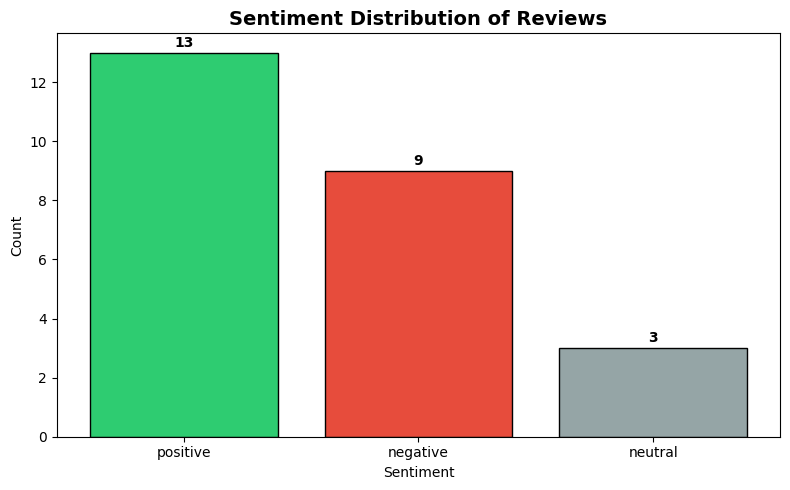

In [6]:
# Visualize sentiment distribution
sentiment_counts = df_reviews['sentiment'].value_counts()
colors = {'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6'}

plt.figure(figsize=(8, 5))
bars = plt.bar(sentiment_counts.index, sentiment_counts.values,
               color=[colors[s] for s in sentiment_counts.index], edgecolor='black')
plt.title('Sentiment Distribution of Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
for bar, count in zip(bars, sentiment_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             str(count), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Exclamation Mark Counting

In [7]:
df_reviews['exclamation_count'] = df_reviews['review_text'].apply(
    lambda x: x.count('!') if isinstance(x, str) else 0
)

print("DataFrame with new 'exclamation_count' column:")
display(df_reviews[['review_text', 'exclamation_count']].head(10))

print(f"\nAverage exclamation marks per review: {df_reviews['exclamation_count'].mean():.2f}")
print(f"Max exclamation marks in a single review: {df_reviews['exclamation_count'].max()}")

DataFrame with new 'exclamation_count' column:


,review_text,exclamation_count
0,I love these headphones! The sound quality is ...,1
1,Worst headphones I have ever bought. The Bluet...,0
2,Great stand for my laptop. Sturdy build and go...,0
3,This stand is terrible. It wobbles and feels c...,1
4,Excellent hub with fast data transfer speeds. ...,1
5,The hub stopped working after 2 weeks. Poor qu...,0
6,Best keyboard I have ever used! The tactile fe...,1
7,Keys started sticking after a month. Not happy...,0
8,Good webcam for the price. Video quality is de...,0
9,Horrible webcam!! The image is blurry and the ...,2



Average exclamation marks per review: 0.64
Max exclamation marks in a single review: 3


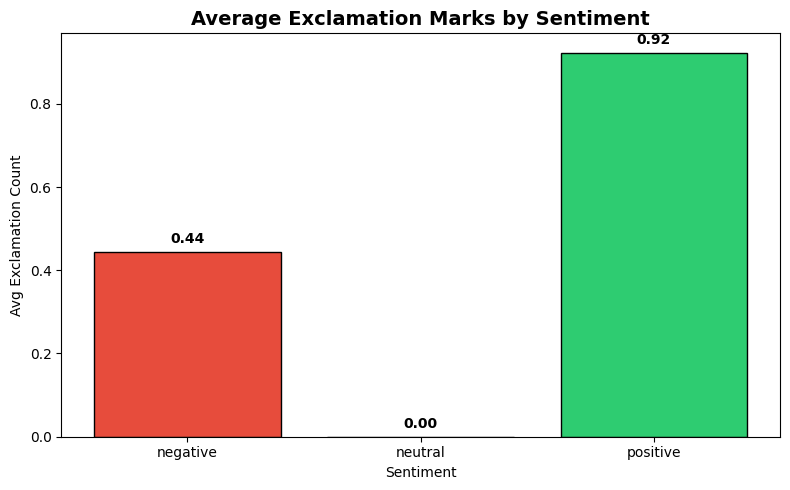

In [8]:
# Compare exclamation counts across sentiments
excl_by_sentiment = df_reviews.groupby('sentiment')['exclamation_count'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(excl_by_sentiment.index, excl_by_sentiment.values,
               color=[colors.get(s, '#3498db') for s in excl_by_sentiment.index], edgecolor='black')
plt.title('Average Exclamation Marks by Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Avg Exclamation Count')
for bar, val in zip(bars, excl_by_sentiment.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

Word Frequency Analysis
> We tokenize all reviews, remove common stopwords, and count word frequencies to discover the most discussed topics.

In [9]:
# Define stopwords
stopwords = {
    "the", "is", "in", "and", "to", "a", "of", "it", "for", "that",
    "was", "on", "are", "with", "this", "i", "my", "me", "but", "not",
    "at", "an", "be", "as", "so", "do", "or", "if", "no", "up", "all",
    "has", "had", "have", "from", "they", "them", "these", "those",
    "its", "too", "very", "just", "than", "after"
}

# Tokenization: extract alphabetic words and convert to lowercase
all_words = (
    df_reviews['review_text']
    .apply(lambda x: re.findall(r'[a-zA-Z]+', str(x).lower()))
    .explode()
)

# Filter out stopwords
filtered_words = all_words[~all_words.isin(stopwords)]

# Count word frequencies
word_counts = Counter(filtered_words)

print("Top 20 Most Common Words:")
print("-" * 35)
for word, count in word_counts.most_common(20):
    print(f"  {word:20s} → {count}")

Top 20 Most Common Words:
-----------------------------------
  quality              → 4
  headphones           → 3
  great                → 3
  good                 → 3
  webcam               → 3
  pad                  → 3
  light                → 3
  sound                → 2
  amazing              → 2
  ever                 → 2
  keeps                → 2
  stand                → 2
  disappointed         → 2
  excellent            → 2
  hub                  → 2
  works                → 2
  product              → 2
  keyboard             → 2
  happy                → 2
  purchase             → 2


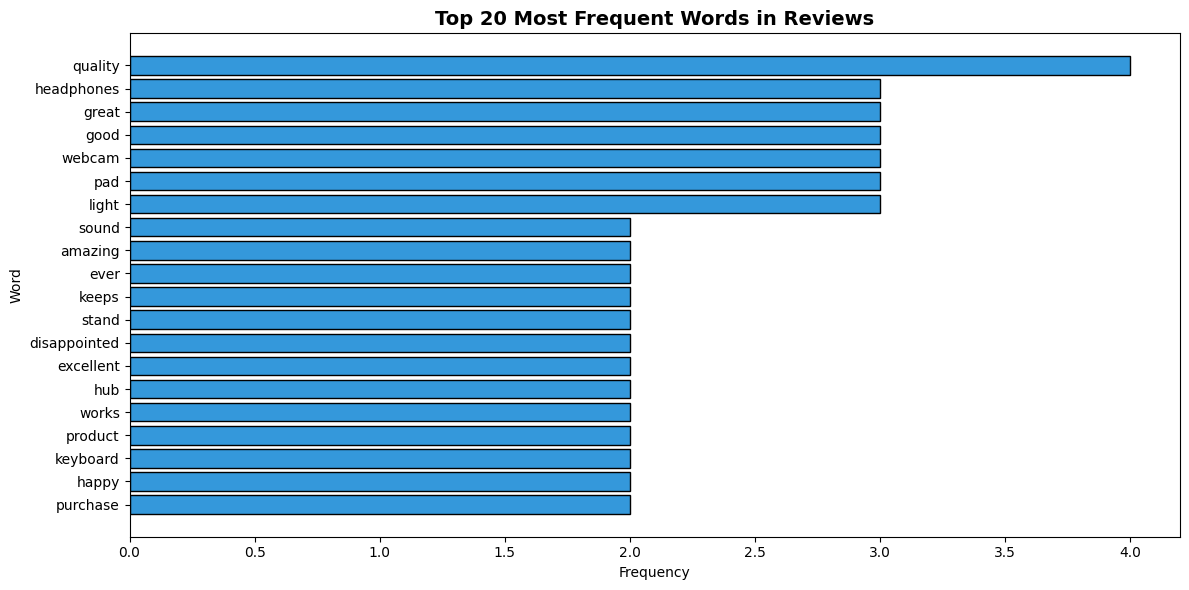

In [10]:
# Visualize top 20 words
top_20 = word_counts.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 6))
plt.barh(list(reversed(words)), list(reversed(counts)), color='#3498db', edgecolor='black')
plt.title('Top 20 Most Frequent Words in Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Frequency')
plt.ylabel('Word')
plt.tight_layout()
plt.show()

In [11]:
print(f"Final DataFrame shape: {df_reviews.shape}")
print(f"Columns: {list(df_reviews.columns)}")
display(df_reviews)

Final DataFrame shape: (25, 7)
Columns: ['review_id', 'product', 'review_text', 'rating', 'emojis', 'sentiment', 'exclamation_count']


,review_id,product,review_text,rating,emojis,sentiment,exclamation_count
0,1,Wireless Headphones,I love these headphones! The sound quality is ...,5,[🎧🔥],positive,1
1,2,Wireless Headphones,Worst headphones I have ever bought. The Bluet...,1,[😡],negative,0
2,3,Laptop Stand,Great stand for my laptop. Sturdy build and go...,4,[],positive,0
3,4,Laptop Stand,This stand is terrible. It wobbles and feels c...,1,[],negative,1
4,5,USB-C Hub,Excellent hub with fast data transfer speeds. ...,5,[👍],positive,1
5,6,USB-C Hub,The hub stopped working after 2 weeks. Poor qu...,2,[],negative,0
6,7,Mechanical Keyboard,Best keyboard I have ever used! The tactile fe...,5,"[😍, ️]",positive,1
7,8,Mechanical Keyboard,Keys started sticking after a month. Not happy...,2,[],positive,0
8,9,Webcam HD,Good webcam for the price. Video quality is de...,3,[],positive,0
9,10,Webcam HD,Horrible webcam!! The image is blurry and the ...,1,[😤],negative,2


## Key Takeaways

### Text Preprocessing Steps:

| Step | Purpose | Example |
|------|---------|--------|
| **Lowercasing** | Normalize case | "Hello" → "hello" |
| **Remove punctuation** | Clean noise | "Hello!!!" → "Hello" |
| **Tokenization** | Split into words | "hello world" → ["hello", "world"] |
| **Stopwords** | Remove common words | ["this", "is", "spam"] → ["spam"] |
| **Stemming** | Reduce to root (fast) | "running" → "run" |
| **Lemmatization** | Reduce to base (smart) | "better" → "good" |

### Vectorization Methods:

| Method | How It Works | Best For |
|--------|--------------|----------|
| **Bag of Words** | Count word occurrences | Simple, interpretable |
| **TF-IDF** | Weight by importance | Better for most tasks |

### Model Results:

| Model | Accuracy | Notes |
|-------|----------|-------|
| Naive Bayes + Count | ~97% | Fast, simple baseline |
| Naive Bayes + TF-IDF | ~96% | Similar performance |
| Logistic Regression + TF-IDF | ~97% | Interpretable coefficients |

